In [ ]:
####################################################################
# Exercise 1
####################################################################
# PROBLEM:
# Analyze short-term residential real estate market trends in Bengaluru using NumPy for numerical analysis and Pandas for data management, then create a comprehensive visualization dashboard.

# TASKS:

# 1. Create Real Estate Dataset (90 days):
#    - Date: Daily dates for 90 consecutive days
#    - Price_High: Random floats ₹80–₹180 lakh (highest listed price per day)
#    - Price_Low: Random floats ₹40–₹95 lakh (always < Price_High)
#    - Avg_Price_per_sqft: Random floats ₹4,000–₹15,000
#    - Units_Listed: Random integers 30–220 per day
#    - Units_Sold: Random integers 5–120 per day (always ≤ Units_Listed)
#    - Home_Loan_Rate: Random floats 8.2–9.8 (%)

#    Store in Pandas DataFrame

# 2. Feature Engineering with Pandas:
#    - Add 'Price_Range' column (High - Low)
#    - Add 'Price_Avg' column ((High + Low) / 2)
#    - Add 'Month' column extracted from Date
#    - Add 'High_Demand_Day' boolean column (True if Units_Sold / Units_Listed ≥ 0.6)
#    - Add 'Market_Segment' based on avg price and demand:
#      * 'Premium_High_Demand': avg > ₹120L and high demand
#      * 'Premium_Low_Demand': avg > ₹120L and low demand
#      * 'Mid_Market_High_Demand': ₹70L–₹120L and high demand
#      * 'Mid_Market_Low_Demand': ₹70L–₹120L and low demand
#      * 'Affordable': avg < ₹70L

# 3. NumPy Statistical Analysis:
#    - Convert Price_High, Price_Low, Units_Listed, Units_Sold to 2D NumPy array
#    - Calculate correlation matrix between all variables
#    - Compute 7-day rolling mean for average prices (use NumPy)
#    - Identify price anomalies (days where high price > mean + 2*std)


# 4. Create Visualization Dashboard:
#    - Plot 1: Line plot of daily high/low prices with trend line (Matplotlib)
#    - Plot 2: Bar chart of total monthly units sold (Matplotlib)
#    - Plot 3: Scatter plot of Avg_Price_per_sqft vs Units_Sold colored by High_Demand_Day (Seaborn)
#    - Plot 4: Histogram of price range distribution (Matplotlib)
#    - Plot 5: Box plot of average prices by month (Seaborn)
#    - Plot 6: Count plot of market segments (Seaborn)
#    - Plot 7: Violin plot of units sold by market segment (Seaborn)


# Your code here:


In [1]:
# Create Real Estate Dataset (90 days):
#    - Date: Daily dates for 90 consecutive days
#    - Price_High: Random floats ₹80–₹180 lakh (highest listed price per day)
#    - Price_Low: Random floats ₹40–₹95 lakh (always < Price_High)
#    - Avg_Price_per_sqft: Random floats ₹4,000–₹15,000
#    - Units_Listed: Random integers 30–220 per day
#    - Units_Sold: Random integers 5–120 per day (always ≤ Units_Listed)
#    - Home_Loan_Rate: Random floats 8.2–9.8 (%)

from datetime import datetime, timedelta
import  random
import pandas as pd
def generateDataset(days = 90):
    startDate = datetime(2024,1,1)
    dateli =[] 
    for i in range(days+1):
        li=[]
        current_date  = (startDate + timedelta(days=i) ).strftime("%Y-%m-%d") 
        li.append(current_date) 
        highprice = round(random.uniform(8000000 , 18000000),2)
        li.append(highprice) 
        lowprice = round(random.uniform(4000000 , 9500000),2)
        li.append(lowprice)
        avg = round(random.uniform(4000 , 15000),2)
        li.append(lowprice)
        ul = random.randint(30 , 220)
        li.append(ul)
        us = random.randint(2 , 120)
        li.append(us)
        loan = round(random.uniform(8.2 , 9.8),2)
        li.append(loan)

        dateli.append(li)
         
    return dateli

Raw = generateDataset(10)
# print(Raw)

Rawdata = pd.DataFrame(Raw , columns=["Date","HighPrice","LowPrice","SqftAvg","UnitListed","UnitSold","HomeLoanRate"])
print(Rawdata)


          Date    HighPrice    LowPrice     SqftAvg  UnitListed  UnitSold  \
0   2024-01-01   8579917.98  4213632.15  4213632.15         176        59   
1   2024-01-02  16589654.42  8477417.55  8477417.55          68        97   
2   2024-01-03   8704568.54  7234292.55  7234292.55         151        67   
3   2024-01-04  15517488.76  7412824.80  7412824.80          80        24   
4   2024-01-05  10023984.28  4191313.51  4191313.51         192         5   
5   2024-01-06  15428867.45  5183119.07  5183119.07         189        28   
6   2024-01-07  13385398.13  4146652.67  4146652.67          30        81   
7   2024-01-08  15558760.79  4914053.93  4914053.93          56       114   
8   2024-01-09  12646350.18  9048389.48  9048389.48          68        52   
9   2024-01-10   8675528.93  7004206.92  7004206.92          62        63   
10  2024-01-11  13497172.34  5781394.89  5781394.89          63        89   

    HomeLoanRate  
0           8.37  
1           9.72  
2           9.50  

In [3]:
#2. Feature Engineering with Pandas:
#    - Add 'Price_Range' column (High - Low)
#    - Add 'Price_Avg' column ((High + Low) / 2)
#    - Add 'Month' column extracted from Date
#    - Add 'High_Demand_Day' boolean column (True if Units_Sold / Units_Listed ≥ 0.6)
#    - Add 'Market_Segment' based on avg price and demand:
#      * 'Premium_High_Demand': avg > ₹120L and high demand
#      * 'Premium_Low_Demand': avg > ₹120L and low demand
#      * 'Mid_Market_High_Demand': ₹70L–₹120L and high demand
#      * 'Mid_Market_Low_Demand': ₹70L–₹120L and low demand
#      * 'Affordable': avg < ₹70L
import numpy as np
Rawdata["PriceRange"] = Rawdata["HighPrice"] - Rawdata["LowPrice"]

Rawdata = Rawdata.assign( AvgPrice = round(((Rawdata["HighPrice"] + Rawdata["LowPrice"]) /2) ,2)
                          , Month = pd.to_datetime(Rawdata["Date"]).dt.month_name()
                          ,HighDemandDay = round(((Rawdata["UnitSold"] + Rawdata["UnitListed"]) /2) ,2)>=6.0
                          )



conditions = [
    (Rawdata["AvgPrice"] > 12000000) & (Rawdata["HighDemandDay"] == True),
    (Rawdata["AvgPrice"] > 12000000) & (Rawdata["HighDemandDay"] == False),

    (Rawdata["AvgPrice"].between(7000000, 12000000)) & (Rawdata["HighDemandDay"] == True),
    (Rawdata["AvgPrice"].between(7000000, 12000000)) & (Rawdata["HighDemandDay"] == False),

    (Rawdata["AvgPrice"] < 7000000)
]

choices = [
    "Premium_High_Demand",
    "Premium_Low_Demand",
    "Mid_Market_High_Demand",
    "Mid_Market_Low_Demand",
    "Affordable"
]
Rawdata["MarketSegment"] = np.select(conditions, choices,
    default="Unknown")



Rawdata

,Date,HighPrice,LowPrice,SqftAvg,UnitListed,UnitSold,HomeLoanRate,PriceRange,AvgPrice,Month,HighDemandDay,MarketSegment
0,2024-01-01,8579917.98,4213632.15,4213632.15,176,59,8.37,4366285.83,6396775.06,January,True,Affordable
1,2024-01-02,16589654.42,8477417.55,8477417.55,68,97,9.72,8112236.87,12533535.98,January,True,Premium_High_Demand
2,2024-01-03,8704568.54,7234292.55,7234292.55,151,67,9.50,1470275.99,7969430.54,January,True,Mid_Market_High_Demand
3,2024-01-04,15517488.76,7412824.80,7412824.80,80,24,8.60,8104663.96,11465156.78,January,True,Mid_Market_High_Demand
4,2024-01-05,10023984.28,4191313.51,4191313.51,192,5,9.08,5832670.77,7107648.90,January,True,Mid_Market_High_Demand
5,2024-01-06,15428867.45,5183119.07,5183119.07,189,28,9.26,10245748.38,10305993.26,January,True,Mid_Market_High_Demand
6,2024-01-07,13385398.13,4146652.67,4146652.67,30,81,8.83,9238745.46,8766025.40,January,True,Mid_Market_High_Demand
7,2024-01-08,15558760.79,4914053.93,4914053.93,56,114,8.92,10644706.86,10236407.36,January,True,Mid_Market_High_Demand
8,2024-01-09,12646350.18,9048389.48,9048389.48,68,52,8.74,3597960.70,10847369.83,January,True,Mid_Market_High_Demand
9,2024-01-10,8675528.93,7004206.92,7004206.92,62,63,8.37,1671322.01,7839867.92,January,True,Mid_Market_High_Demand


In [4]:
#3. NumPy Statistical Analysis:
#    - Convert Price_High, Price_Low, Units_Listed, Units_Sold to 2D NumPy array
#    - Calculate correlation matrix between all variables
#    - Compute 7-day rolling mean for average prices (use NumPy)
#    - Identify price anomalies (days where high price > mean + 2*std)

num_array = Rawdata[["HighPrice","LowPrice","UnitListed","UnitSold"]].to_numpy()
 
np.set_printoptions(suppress=True)
print(num_array  )

corr_matrix = np.corrcoef(num_array, rowvar=False)

print(corr_matrix)


numpyavg = Rawdata["AvgPrice"].to_numpy() 
 
window = np.ones(7) / 7
rolling_mean_7d = np.convolve(numpyavg, window, mode="valid")
rolling_mean_7d 
Rawdata["AvgPrice_7DayMean"] = np.nan
Rawdata.loc[6:, "AvgPrice_7DayMean"] = rolling_mean_7d

price_high = Rawdata["HighPrice"].to_numpy() 
mean_price = np.mean(price_high)
std_price = np.std(price_high)
threshold = mean_price + 2 * std_price
anomaly_mask = price_high > threshold
price_anomalies = Rawdata[anomaly_mask]
print(price_anomalies[["Date", "HighPrice"]])

labels = ["HighPrice", "LowPrice", "UnitListed", "UnitSold"]

corr_df = pd.DataFrame(
    corr_matrix,
    index=labels,
    columns=labels
)

[[ 8579917.98  4213632.15      176.         59.  ]
 [16589654.42  8477417.55       68.         97.  ]
 [ 8704568.54  7234292.55      151.         67.  ]
 [15517488.76  7412824.8        80.         24.  ]
 [10023984.28  4191313.51      192.          5.  ]
 [15428867.45  5183119.07      189.         28.  ]
 [13385398.13  4146652.67       30.         81.  ]
 [15558760.79  4914053.93       56.        114.  ]
 [12646350.18  9048389.48       68.         52.  ]
 [ 8675528.93  7004206.92       62.         63.  ]
 [13497172.34  5781394.89       63.         89.  ]]
[[ 1.          0.18294723 -0.39730914  0.25361705]
 [ 0.18294723  1.         -0.34815536  0.08286678]
 [-0.39730914 -0.34815536  1.         -0.64297265]
 [ 0.25361705  0.08286678 -0.64297265  1.        ]]
Empty DataFrame
Columns: [Date, HighPrice]
Index: []


In [ ]:
# 4. Create Visualization Dashboard:
#    - Plot 1: Line plot of daily high/low prices with trend line (Matplotlib)
#    - Plot 2: Bar chart of total monthly units sold (Matplotlib)
#    - Plot 3: Scatter plot of Avg_Price_per_sqft vs Units_Sold colored by High_Demand_Day (Seaborn)
#    - Plot 4: Histogram of price range distribution (Matplotlib)
#    - Plot 5: Box plot of average prices by month (Seaborn)
#    - Plot 6: Count plot of market segments (Seaborn)
#    - Plot 7: Violin plot of units sold by market segment (Seaborn)


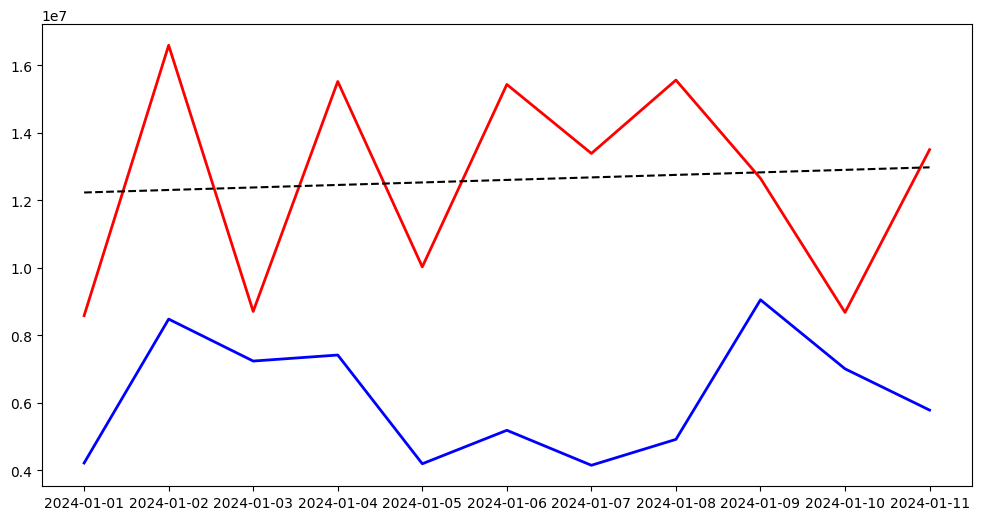

In [5]:
import matplotlib.pyplot as plt
import numpy as np


dates = Rawdata["Date"]
high = Rawdata["HighPrice"]
low = Rawdata["LowPrice"]

plt.figure(figsize=(12, 6))

plt.plot(dates, high, label="High Price", color="red", linewidth=2)
plt.plot(dates, low, label="Low Price", color="blue", linewidth=2)

x = np.arange(len(high))    
z = np.polyfit(x, high, 1) 
trend = np.poly1d(z)

plt.plot(dates, trend(x), linestyle="--", color="black", label="Trend Line")


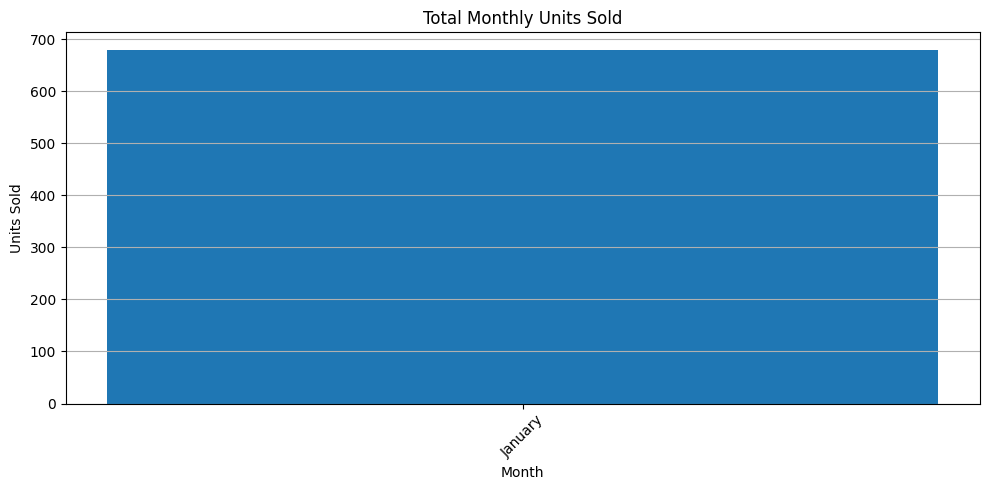

In [6]:
monthly_units = Rawdata.groupby("Month")["UnitSold"].sum()
plt.figure(figsize=(10, 5))
plt.bar(monthly_units.index, monthly_units.values)

plt.title("Total Monthly Units Sold")
plt.xlabel("Month")
plt.ylabel("Units Sold")
plt.xticks(rotation=45)
plt.grid(axis="y")

plt.tight_layout()
plt.show()